# Previsão de Quantidade de Passageiros

Neste notebook, vamos analisar o dataset de movimentação de passageiros e criar um modelo preditivo para estimar a quantidade de passageiros (`Total Passageiros`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Configuração de plotagem
plt.style.use('ggplot')

## 1. Carregamento dos Dados
Vamos carregar o arquivo CSV, ajustando o separador para ponto e vírgula (`;`) e corrigindo a codificação.

In [4]:
# Definindo o caminho do arquivo (considerando a estrutura de pastas atual)
path = Path("dataset/movimentacao_sobe_desce_29-11-2018-004.csv")

# Carregando o dataset
try:
    df = pd.read_csv(path, sep=';', encoding='latin1')
    print("Dados carregados com sucesso!")
except FileNotFoundError:
    print(f"Arquivo não encontrado em: {path}. Verifique o caminho.")

# Visualizando as primeiras linhas
df.head()

Dados carregados com sucesso!


,Linha/SubLinha,Servico,Consorcio,Data Pesquisa,Dia Semana,Rota,Hora Viagem,Sequencia do PED,Endereco do PED,Embarque,Desembarque,Saldo,Total Passageiros,Latitude,Longitude
0,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,1,RUA DAS ALMAS 122 ...,9,0,9,41,"-19,833061","-43,883134"
1,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,2,RUA DAS ALMAS 96 ...,3,0,12,41,"-19,830729","-43,884487"
2,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,3,RUA DAS ALMAS 22 ...,4,0,16,41,"-19,830751","-43,886302"
3,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,4,RUA ANJO AZUL 69 ...,3,0,19,41,"-19,82981","-43,888611"
4,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,5,RUA ANJO AZUL 37 ...,2,0,21,41,"-19,830045","-43,889373"


## 2. Limpeza e Pré-processamento
- Remover espaços em branco dos nomes das colunas.
- Converter colunas numéricas (Latitude, Longitude) que estão como strings com vírgula.
- Ajustar tipos de dados de data e hora.

In [5]:
# Remover espaços dos nomes das colunas
df.columns = df.columns.str.strip()

# Converter Latitude e Longitude (substituir ',' por '.')
cols_float = ['Latitude', 'Longitude']
for col in cols_float:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Verificar informações do dataframe após correção
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116094 entries, 0 to 116093
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Linha/SubLinha     116094 non-null  object 
 1   Servico            116094 non-null  object 
 2   Consorcio          116094 non-null  object 
 3   Data Pesquisa      116094 non-null  object 
 4   Dia Semana         116094 non-null  object 
 5   Rota               116094 non-null  object 
 6   Hora Viagem        116094 non-null  object 
 7   Sequencia do PED   116094 non-null  int64  
 8   Endereco do PED    116094 non-null  object 
 9   Embarque           116094 non-null  int64  
 10  Desembarque        116094 non-null  int64  
 11  Saldo              116094 non-null  int64  
 12  Total Passageiros  116094 non-null  int64  
 13  Latitude           116094 non-null  float64
 14  Longitude          116094 non-null  float64
dtypes: float64(2), int64(5), object(8)
memory usage: 13

## 3. Engenharia de Features
Vamos extrair informações úteis de horário e preparar as variáveis categóricas.

In [6]:
# Extrair a hora da coluna 'Hora Viagem'
# Garantir que a coluna Hora seja numérica
df['Hora'] = pd.to_datetime(df['Hora Viagem'], format='%H:%M:%S', errors='coerce').dt.hour
df['Hora'] = df['Hora'].fillna(0).astype(int)  # Preencher nulos com 0 ou outro valor adequado

# Codificar variáveis categóricas
le_linha = LabelEncoder()
df['Linha_Encoded'] = le_linha.fit_transform(df['Linha/SubLinha'].astype(str))

le_sem = LabelEncoder()
df['Semana_Encoded'] = le_sem.fit_transform(df['Dia Semana'].astype(str))

# Seleção de Features para o Modelo
features = ['Linha_Encoded', 'Semana_Encoded', 'Hora', 'Sequencia do PED', 'Latitude', 'Longitude']
target = 'Total Passageiros'

# Verificação
print("Features selecionadas:", features)
print("\nTipos das features:")
print(df[features].dtypes)
print("\nPrimeiras linhas do X:")
print(df[features].head())


Features selecionadas: ['Linha_Encoded', 'Semana_Encoded', 'Hora', 'Sequencia do PED', 'Latitude', 'Longitude']

Tipos das features:
Linha_Encoded         int64
Semana_Encoded        int64
Hora                  int64
Sequencia do PED      int64
Latitude            float64
Longitude           float64
dtype: object

Primeiras linhas do X:
   Linha_Encoded  Semana_Encoded  Hora  Sequencia do PED   Latitude  Longitude
0              0               3     0                 1 -19.833061 -43.883134
1              0               3     0                 2 -19.830729 -43.884487
2              0               3     0                 3 -19.830751 -43.886302
3              0               3     0                 4 -19.829810 -43.888611
4              0               3     0                 5 -19.830045 -43.889373


## 4. Análise Exploratória Rápida

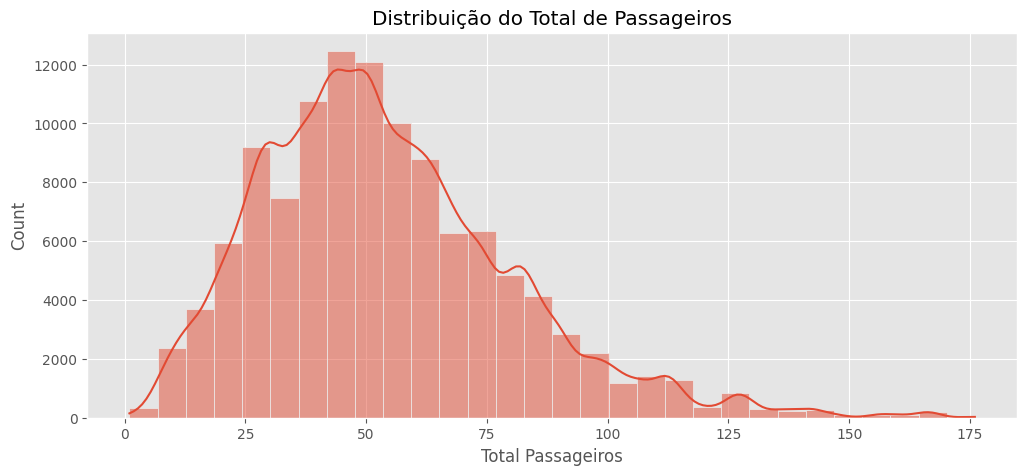

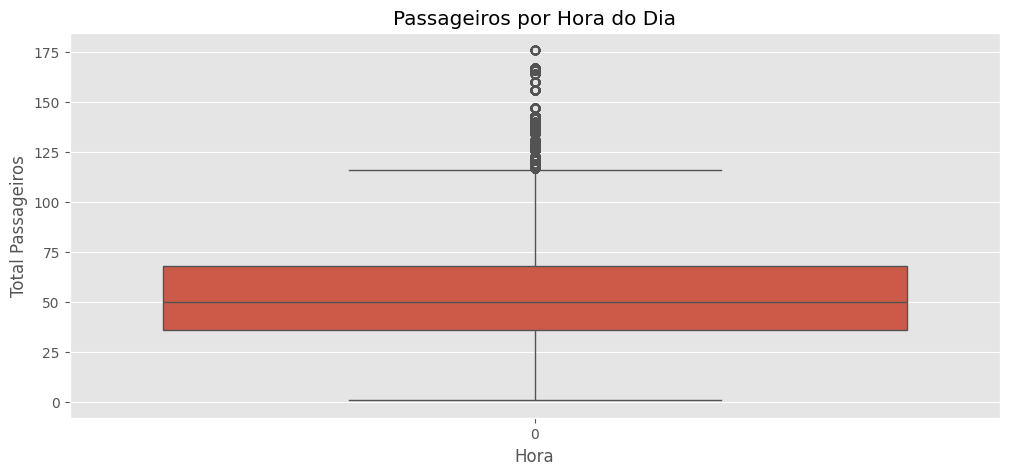

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(df[target], bins=30, kde=True)
plt.title('Distribuição do Total de Passageiros')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='Hora', y=target, data=df)
plt.title('Passageiros por Hora do Dia')
plt.show()

## 5. Modelagem Preditiva
Vamos dividir os dados em treino e teste e treinar um modelo RandomForestRegressor.

In [8]:
X = df[features]
y = df[target]

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instanciar e Treinar Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 14.95
RMSE: 20.10
R2 Score: 0.41


## 6. Visualização dos Resultados
Comparando Real vs Previsto.

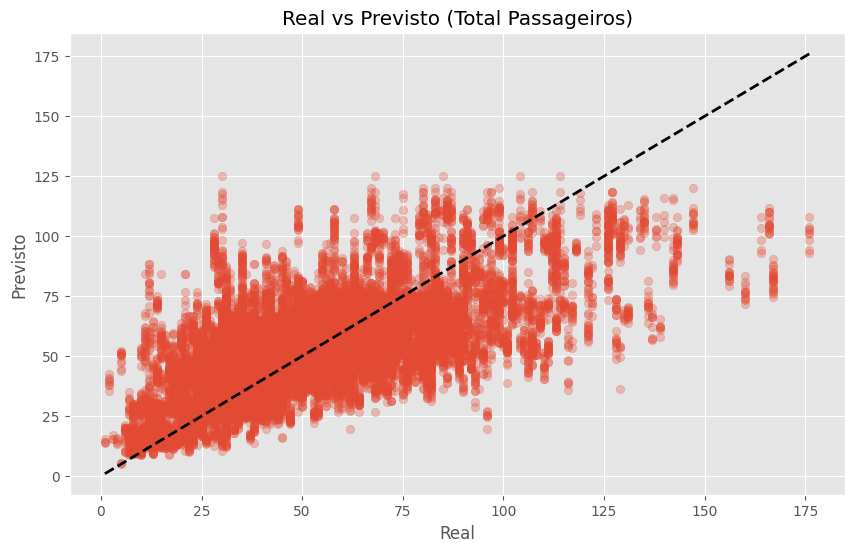

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.title('Real vs Previsto (Total Passageiros)')
plt.show()

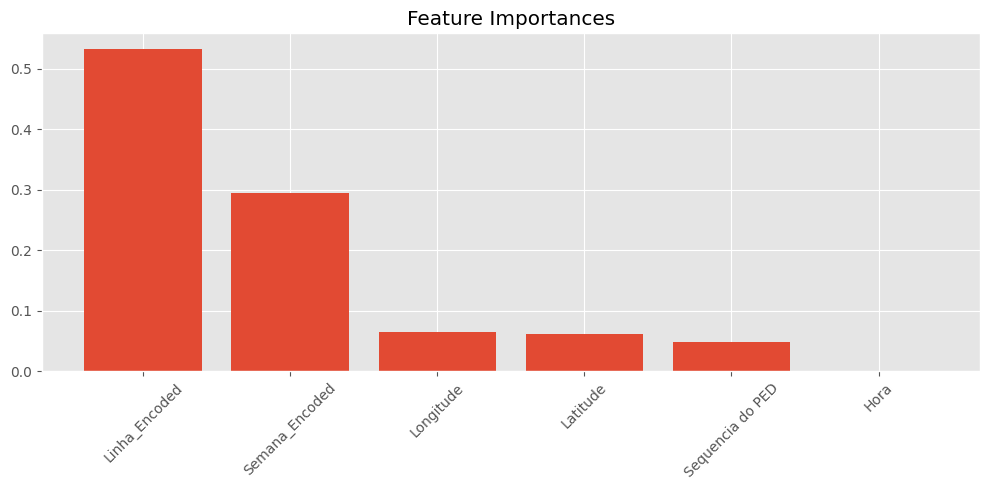

In [10]:
# Importância das Features
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import torch
from torch.utils.data import DataLoader, Dataset

# 1. Garantir que a classe TimeSeriesDataset esteja definida
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_length):
        self.series = torch.tensor(series, dtype=torch.float32)
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

# 2. Preparar os dados da série temporal (usando 'Total Passageiros')
# Importante: Garantir que os dados não sejam embaralhados antes da divisão temporal
serie_temporal = df['Total Passageiros'].values

# Divisão dos dados (ex: 70% treino, 20% validação, 10% teste)
n = len(serie_temporal)
train_end = int(n * 0.7)
valid_end = int(n * 0.9)

rail_train = serie_temporal[:train_end]
rail_valid = serie_temporal[train_end:valid_end]
rail_test = serie_temporal[valid_end:]

# 3. Configuração dos DataLoaders (conforme sua imagem)
window_length = 56
batch_size = 32

train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=batch_size)

test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=batch_size)

print(f"Tamanhos dos conjuntos: Treino={len(train_set)}, Validação={len(valid_set)}, Teste={len(test_set)}")

Tamanhos dos conjuntos: Treino=81209, Validação=23163, Teste=11554
